采用模拟退火算法，求解函数的最小值 
$$f(x, y) = 5cos(xy) + xy + y^3$$
$$x, y \in [-5, 5]$$

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 使用微软雅黑
plt.rcParams["axes.unicode_minus"] = False         # 解决负号显示问题

In [7]:
def target_function(x, y):
    return 5 * np.cos(x * y) + x * y + y ** 3

def generate_neighbor(x, y, step=0.01, x_range=(-5, 5), y_range=(-5, 5)):
    """
    随机扰动x和y, 产生新解 
    
    :param x: 当前解x
    :param y: 当前解y
    :param step: 步长
    :param x_range: x取值区间
    :param y_range: y取值区间
    :return new_x: 新解x
    :return new_y: 新解y
    """
    new_x = x + (random.random() * 2 - 1) * step     # (random.random() * 2 - 1) 随机生成[-1, 1)区间中的小数
    new_y = y + (random.random() * 2 - 1) * step
    new_x = max(x_range[0], min(new_x, x_range[1]))  # 边界处理
    new_y = max(y_range[0], min(new_y, y_range[1]))
    return new_x, new_y

def SA_solvefunc_sampling(func, cur_x, cur_y, x_range, y_range, step, t, L):
    """ 
    模拟退火算法求解函数最小值, 内部循环采样过程

    :param func: 目标函数
    :param cur_x: 当前解x
    :param cur_y: 当前解y
    :param x_range: x取值区间
    :param y_range: y取值区间
    :param step: 步长
    :param t: 温度
    :param L: 采样次数
    :return cur_x: 循环结束时的当前解x
    :return cur_y: 循环结束时的当前解y
    :return best_x: 最优解x
    :return best_y: 最优解y
    """
    cur_f = func(cur_x, cur_y)      # 当前解的函数值
    best_x = cur_x                  # 初始化最优解
    best_y = cur_y 
    best_f = cur_f

    for _ in range(L):
        new_x, new_y = generate_neighbor(cur_x, cur_y, step, x_range, y_range)
        new_f = func(new_x, new_y)
        
        delta = new_f - cur_f        # 新解和当前解的函数值的差值
        if delta < 0:                # 新解更优，更新当前解
            cur_x = new_x 
            cur_y = new_y 
            cur_f = new_f 
            if cur_f < best_f:        # 更新最优解
                best_x = cur_x
                best_y = cur_y 
                best_f = cur_f 
        else:                         # 当新解更差时，仍有一定概率将新解作为当前解
            if random.random() < np.exp(-delta/t):        # 新解越差，接受概率越小；温度越高，接受概率越大
                cur_x = new_x 
                cur_y = new_y 
                cur_f = new_f 

    return (cur_x, cur_y, best_x, best_y)

In [8]:
def visualize_results(func, history, x_range=(-5, 5), y_range=(-5, 5)):
    """
    绘制函数三维曲面
    
    :param func: 函数
    :param history: SA算法每轮当前解
    :param x_range: x取值范围
    :param y_range: y取值范围
    """
    # 生成网格数据
    x = np.linspace(x_range[0], x_range[1], 200)  # x轴采样200个点，密度越高曲面越平滑
    y = np.linspace(y_range[0], y_range[1], 200)  # y轴采样200个点
    X, Y = np.meshgrid(x, y)                      # 生成二维网格（X, Y 均为 200×200 矩阵）
    f = func(X, Y)                     # 计算每个网格点的函数值（Z 为 200×200 矩阵）

    # 创建3D图形对象
    fig = plt.figure(figsize=(12, 8))  # 设置画布大小
    ax = fig.add_subplot(111, projection='3d')  # 创建3D子图

    # 绘制3D曲面图
    # rstride/cstride：控制曲面网格线的密度（值越小密度越高，2-5较合适）
    # cmap：颜色映射（如 viridis、plasma，可调整视觉效果）
    # alpha：透明度（0-1，0.7可兼顾曲面层次和背景可见性）
    surf = ax.plot_surface(
        X, Y, f,
        rstride=2, cstride=2,
        cmap='viridis',
        alpha=0.8,
        edgecolor='none'  # 隐藏曲面边缘线，避免画面杂乱
    )

    # 添加颜色条（显示Z值与颜色的对应关系）
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20)
    cbar.set_label('函数值 f(x, y)', fontsize=12)  # 颜色条标签

    # 设置坐标轴和标题
    ax.set_xlabel('x', fontsize=12, labelpad=10)  # x轴标签（labelpad调整与轴的距离）
    ax.set_ylabel('y', fontsize=12, labelpad=10)  # y轴标签
    ax.set_zlabel('f(x, y)', fontsize=12, labelpad=10)  # z轴标签（函数值）
    ax.set_title('函数三维曲面图', fontsize=14, pad=20)

    # 调整视角（elev：仰角，azim：方位角，可按需修改）
    # ax.view_init(elev=20, azim=45)  # 仰角20°、方位角45°，便于观察函数低谷

    # 显示算法每轮当前解的位置
    cur_x_all = history['cur_x_all']
    cur_y_all = history['cur_y_all']
    cur_f_all = history['cur_f_all']

    ax.scatter(
        cur_x_all, cur_y_all, cur_f_all,
        c='darkblue', s=30, alpha=0.9,
        edgecolor='white', linewidth=0.5,  # 白色边缘增强辨识度
        label='迭代过程当前解' 
        )
    
    # 显示最优解的位置
    best_x = history['best_x']
    best_y = history['best_y']
    best_f = history['best_f']

    ax.scatter(
        best_x, best_y, best_f,
        c='red', s=400, marker='*', alpha=1.0,
        edgecolor='red', linewidth=3,
        label=f'全局最优解: ({best_x:.2f}, {best_y:.2f})'
    )

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)  # 显示图例
    # 显示图形
    plt.tight_layout()  # 自动调整布局，避免标签被截断
    plt.show()

In [9]:
def SA_solvefunc(func, x_range=(-5, 5), y_range=(-5, 5), S=0.01, tolerance=1e-8, T0=100, T_end=0.01, K=0.99, L=100):
    """ 
    模拟退火算法求解函数最小值

    :param func: 目标函数
    :param x_range: x取值区间
    :param y_range: y取值区间
    :param S: 步长
    :param tolerance: 容差
    :param T0: 初始温度
    :param T_end: 最终温度
    :param K: 温度衰减系数
    :param L: 内部循环采样次数
    """
    # 初始化当前解
    cur_x = random.uniform(x_range[0], x_range[1])
    cur_y = random.uniform(y_range[0], y_range[1])
    cur_f = func(cur_x, cur_y)           # 初始化当前解的函数值
    # 初始化最优解
    best_x = cur_x
    best_y = cur_y 
    best_f = cur_f 

    t = T0          # 每轮的温度
    epoch = 0       # 记录外层循环次数
    count = 0       # 记录最优解优化幅度不大于容差的连续次数

    history = {
        'cur_x_all': [cur_x],   # 保存每轮迭代的当前解，便于后续分析or绘图
        'cur_y_all': [cur_y],
        'cur_f_all': [cur_f]
    }

    while t > T_end:            # 每轮温度不断下降
        cur_x_inner, cur_y_inner, best_x_inner, best_y_inner = SA_solvefunc_sampling(func, cur_x, cur_y, x_range, y_range, S, t, L)
        cur_x = cur_x_inner            # 更新外层循环当前解
        cur_y = cur_y_inner          
        cur_f = func(cur_x, cur_y)

        best_f_inner = func(best_x_inner, best_y_inner)    # 更新外层循环最优解
        if best_f - best_f_inner < tolerance:              # 最优解在这次内部循环中，优化的幅度小于容差
            count += 1
        else:
            count = 0

        if best_f_inner < best_f:
            best_x = best_x_inner
            best_y = best_y_inner
            best_f = best_f_inner 
        
        t *= K                                             # 降温 

        epoch += 1
        history['cur_x_all'].append(cur_x)
        history['cur_y_all'].append(cur_y)
        history['cur_f_all'].append(cur_f)
  
        # if count > 300:                                     # 优化的幅度小于容差连续300次，认为收敛
        #     break

    history['best_x'] = best_x  # 存一下最优解 
    history['best_y'] = best_y 
    history['best_f'] = best_f
    visualize_results(func, history, x_range, y_range)
    print(f"算法结束, 共{epoch}轮, 最优解x: {best_x:.2f}, y: {best_y:.2f}, 函数值: {best_f}")

运行算法

由于模拟退火的随机性，有可能算法会得出局部极小值 \
经过多次算法运行，发现: \
初始温度如果设置为100，降温过程较快，有可能导致高温时随机搜索不够充分，陷入局部极小值 \
步长因子如果设置为0.01, 也容易导致搜索不够广泛，陷入局部极小值 \
所以这里尝试设置初始温度1000，步长因子0.1，算法运行结果相对稳定，大约为x: 4.44, y: -5.00, 函数值: -152 \
另外，容差，即当连续n轮最优解变化幅度不大于容差，认为算法收敛,感觉作用不大，故代码中注释掉了

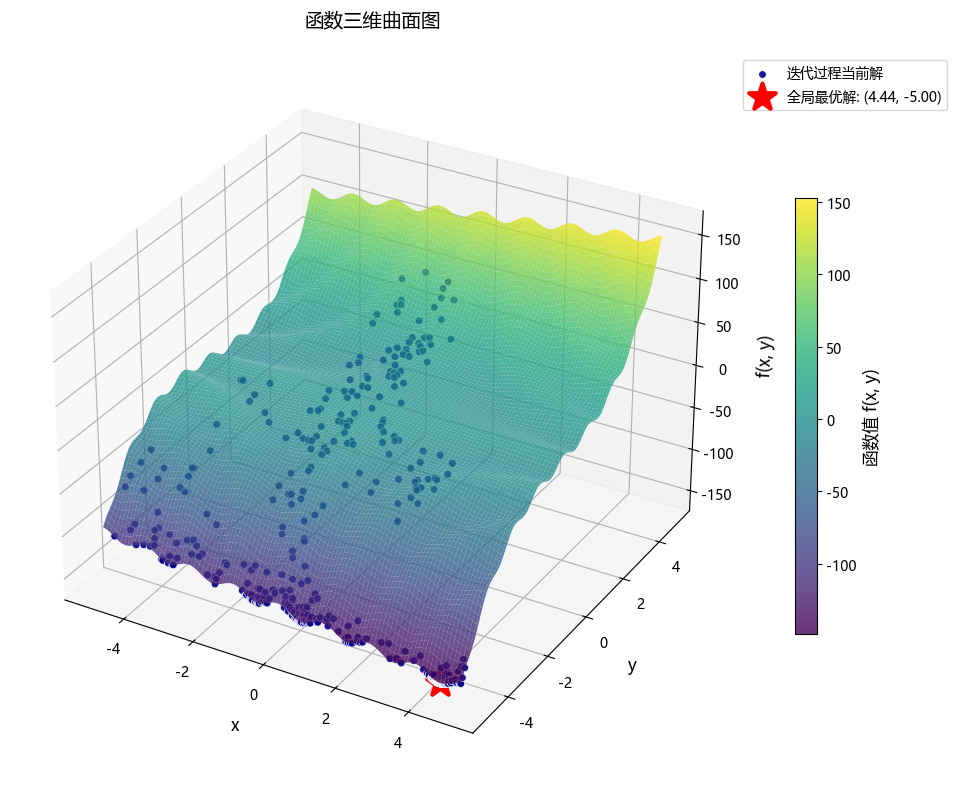

算法结束, 共917轮, 最优解x: 4.44, y: -5.00, 函数值: -152.09148598141707


In [10]:
func = target_function
x_range = (-5, 5)    # 元组，(x下限, x上限)
y_range = (-5, 5)

S = 0.1            # 步长因子，按步长因子随机产生新解
tolerance = 1e-8   # 容差，即当连续n轮最优解变化幅度不大于容差，认为算法收敛

T0 = 100         # 初始温度
T_end = 0.01       # 最终温度
K = 0.99           # 温度衰减系数
L = 100            # 每轮温度，生成新可行解的数量

SA_solvefunc(func, x_range, y_range, S, tolerance, T0, T_end, K, L)